# STEAD and INSTANCE exploraroty analysis

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import seisbench.data as sbd
import pandas as pd
import numpy as np

In [ ]:
sns.set_theme(style="whitegrid")

print("Downloading/Loading metadata for STEAD and INSTANCE...")
stead = sbd.STEAD(component_order="ZNE")
stead_train = sbd.STEAD(component_order="ZNE").train()
stead_test = sbd.STEAD(component_order="ZNE").test()
instance = sbd.InstanceCountsCombined(component_order="ZNE")
instance_train = sbd.InstanceCountsCombined(component_order="ZNE").train()
instance_test = sbd.InstanceCountsCombined(component_order="ZNE").test()

df_stead = stead.metadata
df_stead_train = stead_train.metadata
df_stead_test = stead_test.metadata

df_instance = instance.metadata
df_instance_train = instance_train.metadata
df_instance_test = instance_test.metadata

stead_cols = stead.metadata.columns.tolist()
instance_cols = instance.metadata.columns.tolist()

print(f"STEAD traces: total: {len(df_stead):,} - train: {len(df_stead_train):,} - test: {len(df_stead_test)}")
print(f"INSTANCE traces: total: {len(df_instance):,} - train: {len(df_instance_train):,} - test: {len(df_instance_test)}")

Downloading/Loading metadata for STEAD and INSTANCE...
STEAD traces: 1,075,808
INSTANCE traces: 779,265


## Dummy dataset

In [4]:
def generate_dummy_data(n_samples, ds_type):
    """Generates dummy seismic metadata with realistic missing values."""
    if ds_type == "stead":
        cat_col = 'trace_category'
        eq_label = 'earthquake_local'
        noise_label = 'noise'
        p_col = 'trace_p_arrival_sample'
        s_col = 'trace_s_arrival_sample'
    else: # INSTANCE
        cat_col = 'trace_dataset'
        eq_label = 'InstanceCounts'
        noise_label = 'InstanceNoise'
        p_col = 'trace_P_arrival_sample'
        s_col = 'trace_S_arrival_sample'

    # 1. Generate Categories (~60% Earthquakes, 40% Noise)
    categories = np.random.choice([eq_label, noise_label], size=n_samples, p=[0.6, 0.4])
    df = pd.DataFrame({cat_col: categories})
    
    # 2. Initialize Arrival Samples (Noise traces naturally stay as NaN)
    df[p_col] = np.nan
    df[s_col] = np.nan
    
    # 3. Generate Arrival Samples for Earthquakes (5 to 30 seconds -> 500 to 3000 samples)
    eq_mask = df[cat_col] == eq_label
    n_eq = eq_mask.sum()
    
    # Placing P-waves earlier (5-15s) and S-waves later (16-30s) so S always follows P
    df.loc[eq_mask, p_col] = np.random.randint(500, 1500, size=n_eq).astype(float)
    df.loc[eq_mask, s_col] = np.random.randint(1600, 3000, size=n_eq).astype(float)
    
    # 4. Introduce Missing Waves for Earthquakes (The "Overlap" logic)
    eq_indices = df[eq_mask].index.tolist()
    np.random.shuffle(eq_indices)
    
    # Roughly 15% missing P, 15% missing S, and 10% missing both
    n_missing_p = int(n_eq * 0.15)
    n_missing_s = int(n_eq * 0.15)
    n_missing_both = int(n_eq * 0.10)
    
    idx_missing_both = eq_indices[:n_missing_both]
    idx_missing_p = eq_indices[n_missing_both : n_missing_both + n_missing_p]
    idx_missing_s = eq_indices[n_missing_both + n_missing_p : n_missing_both + n_missing_p + n_missing_s]
    
    df.loc[idx_missing_both, [p_col, s_col]] = np.nan
    df.loc[idx_missing_p, p_col] = np.nan
    df.loc[idx_missing_s, s_col] = np.nan
    
    return df

print("Generating dummy data for STEAD and INSTANCE...")

# Generate Train and Test splits
df_stead_train = generate_dummy_data(10000, "stead")
df_stead_test = generate_dummy_data(2500, "stead")

df_instance_train = generate_dummy_data(12000, "instance")
df_instance_test = generate_dummy_data(3000, "instance")

# Create the master DataFrames by concatenating the splits
df_stead = pd.concat([df_stead_train, df_stead_test], ignore_index=True)
df_instance = pd.concat([df_instance_train, df_instance_test], ignore_index=True)

print("--- Dummy Data Ready ---")
print(f"STEAD    | Train: {len(df_stead_train)} | Test: {len(df_stead_test)} | Total: {len(df_stead)}")
print(f"INSTANCE | Train: {len(df_instance_train)} | Test: {len(df_instance_test)} | Total: {len(df_instance)}")

Generating dummy data for STEAD and INSTANCE...
--- Dummy Data Ready ---
STEAD    | Train: 10000 | Test: 2500 | Total: 12500
INSTANCE | Train: 12000 | Test: 3000 | Total: 15000


## Earthquake traces vs Noise traces Ratio

In [5]:
# Prepare STEAD
s_train = pd.DataFrame({'Category': df_stead_train['trace_category'].map({'noise': 'Noise', 'earthquake_local': 'Earthquake'}), 'Split': 'Train'})
s_test = pd.DataFrame({'Category': df_stead_test['trace_category'].map({'noise': 'Noise', 'earthquake_local': 'Earthquake'}), 'Split': 'Test'})
s_total = pd.DataFrame({'Category': df_stead['trace_category'].map({'noise': 'Noise', 'earthquake_local': 'Earthquake'}), 'Split': 'Total'})
df_stead_plot = pd.concat([s_train, s_test, s_total])

# Prepare INSTANCE
i_train = pd.DataFrame({'Category': df_instance_train['trace_dataset'].map({'InstanceNoise': 'Noise', 'InstanceCounts': 'Earthquake'}), 'Split': 'Train'})
i_test = pd.DataFrame({'Category': df_instance_test['trace_dataset'].map({'InstanceNoise': 'Noise', 'InstanceCounts': 'Earthquake'}), 'Split': 'Test'})
i_total = pd.DataFrame({'Category': df_instance['trace_dataset'].map({'InstanceNoise': 'Noise', 'InstanceCounts': 'Earthquake'}), 'Split': 'Total'})
df_instance_plot = pd.concat([i_train, i_test, i_total])

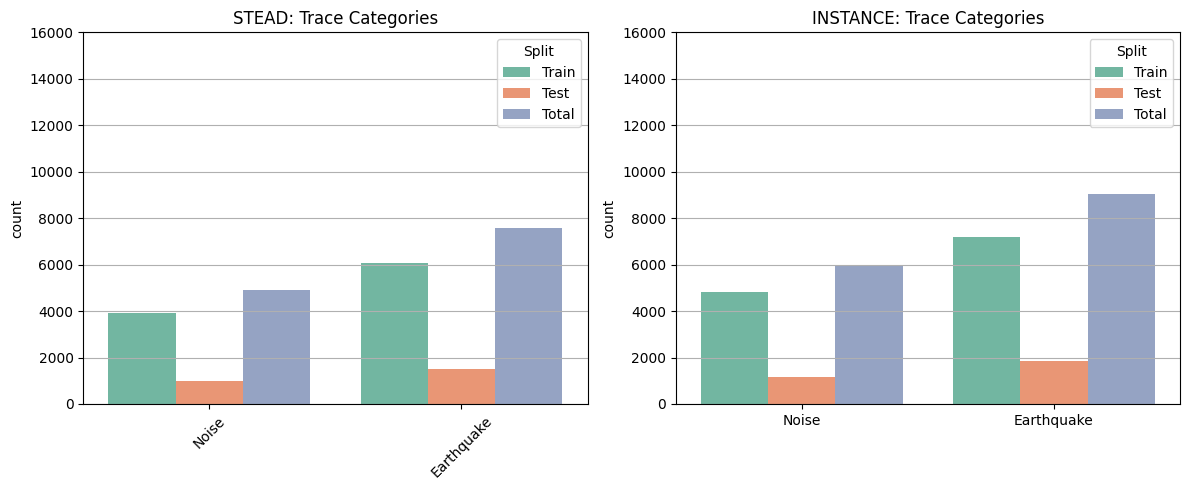

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

palette = sns.color_palette("Set2", n_colors=3)

# STEAD
sns.countplot(
    data=df_stead_plot, 
    x="Category", 
    hue="Split", 
    ax=axes[0], 
    order=["Noise", "Earthquake"], 
    palette={"Train": palette[0], "Test": palette[1], "Total": palette[2]}
)
axes[0].set_title("STEAD: Trace Categories")
axes[0].set_xlabel("")
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_ylim(0, 900000)
axes[0].grid(axis='y')

# INSTANCE
sns.countplot(
    data=df_instance_plot, 
    x="Category", 
    hue="Split", 
    ax=axes[1], 
    order=["Noise", "Earthquake"], 
    palette={"Train": palette[0], "Test": palette[1], "Total": palette[2]}
)
axes[1].set_title("INSTANCE: Trace Categories")
axes[1].set_xlabel("")
axes[1].set_ylim(0, 900000)
axes[1].grid(axis='y')
plt.tight_layout()
plt.show()

## Phase arrival time distributions

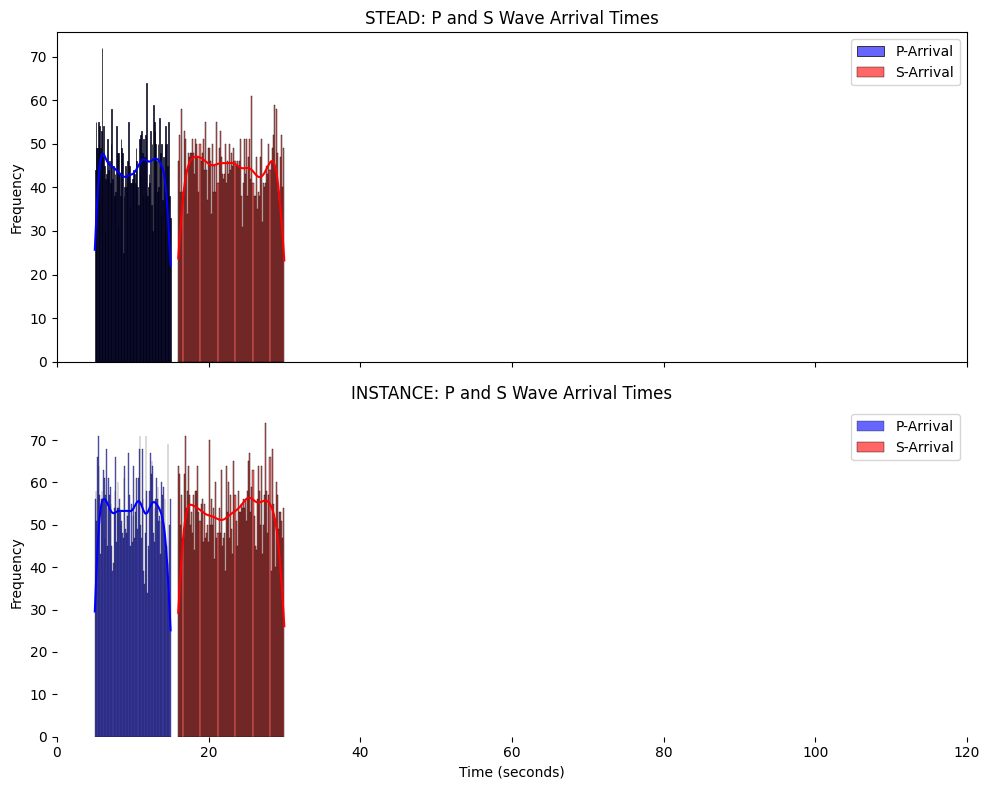

In [25]:
SAMPLING_RATE = 100.0

stead_eqs = df_stead[df_stead['trace_category'] == 'earthquake_local'].dropna(subset=['trace_p_arrival_sample', 'trace_s_arrival_sample'])
instance_eqs = df_instance[df_instance['trace_dataset'] == 'InstanceCounts'].dropna(subset=['trace_P_arrival_sample', 'trace_S_arrival_sample'])

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(10, 8), sharex=True)

# --- STEAD Plot (Top) ---
# Divide sample index by sampling rate to get seconds
sns.histplot(stead_eqs['trace_p_arrival_sample'] / SAMPLING_RATE, bins=100, color='blue', label='P-Arrival', alpha=0.6, kde=True, ax=axes[0])
sns.histplot(stead_eqs['trace_s_arrival_sample'] / SAMPLING_RATE, bins=100, color='red', label='S-Arrival', alpha=0.6, kde=True, ax=axes[0])

axes[0].set_title("STEAD: P and S Wave Arrival Times")
axes[0].set_ylabel("Frequency")
axes[0].legend()

# --- INSTANCE Plot (Bottom) ---
sns.histplot(instance_eqs['trace_P_arrival_sample'] / SAMPLING_RATE, bins=100, color='blue', label='P-Arrival', alpha=0.6, kde=True, ax=axes[1])
sns.histplot(instance_eqs['trace_S_arrival_sample'] / SAMPLING_RATE, bins=100, color='red', label='S-Arrival', alpha=0.6, kde=True, ax=axes[1])

axes[1].set_title("INSTANCE: P and S Wave Arrival Times")
axes[1].set_xlabel("Time (seconds)")
axes[1].set_ylabel("Frequency")
axes[1].legend()

plt.box(False)
plt.xlim(0, 120)
plt.tight_layout()
plt.show()

## Magnitude Distribution Comparison

In [10]:
stead_mags = df_stead['source_magnitude'].dropna()
instance_mags = df_instance['source_magnitude'].dropna()

fig, ax = plt.subplots(figsize=(10, 5))
sns.kdeplot(stead_mags, fill=True, label="STEAD", color="blue", alpha=0.4)
sns.kdeplot(instance_mags, fill=True, label="INSTANCE", color="orange", alpha=0.4)

ax.set_title("Distribution of Earthquake Magnitudes")
ax.set_xlabel("Magnitude")
ax.set_ylabel("Density")
ax.set_xlim(0, 8)
ax.legend()
plt.show()

KeyError: 'source_magnitude'

## Distribution of source distance

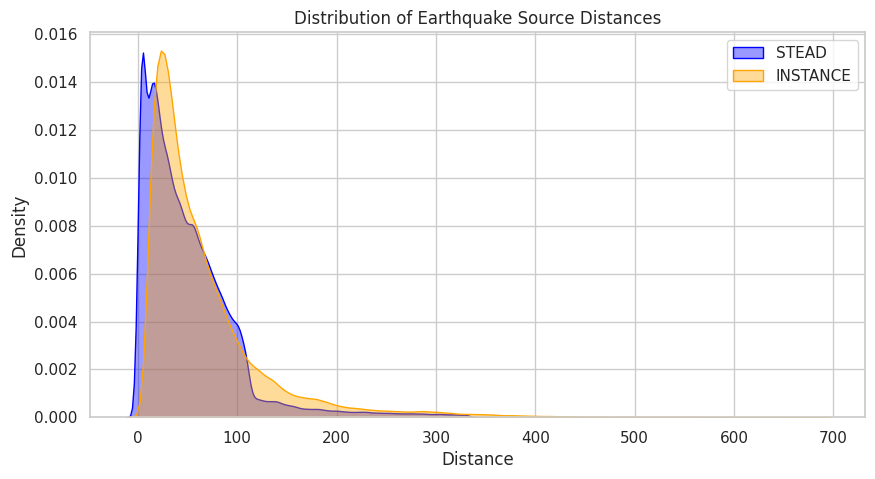

In [5]:
stead_dist = df_stead['source_distance_km'].dropna()
instance_dist = df_instance['path_hyp_distance_km'].dropna()

fig, ax = plt.subplots(figsize=(10, 5))
sns.kdeplot(stead_dist, fill=True, label="STEAD", color="blue", alpha=0.4)
sns.kdeplot(instance_dist, fill=True, label="INSTANCE", color="orange", alpha=0.4)

ax.set_title("Distribution of Earthquake Source Distances")
ax.set_xlabel("Distance")
ax.set_ylabel("Density")
ax.legend()
plt.show()

## S-P Interval and Source Distance Analysis

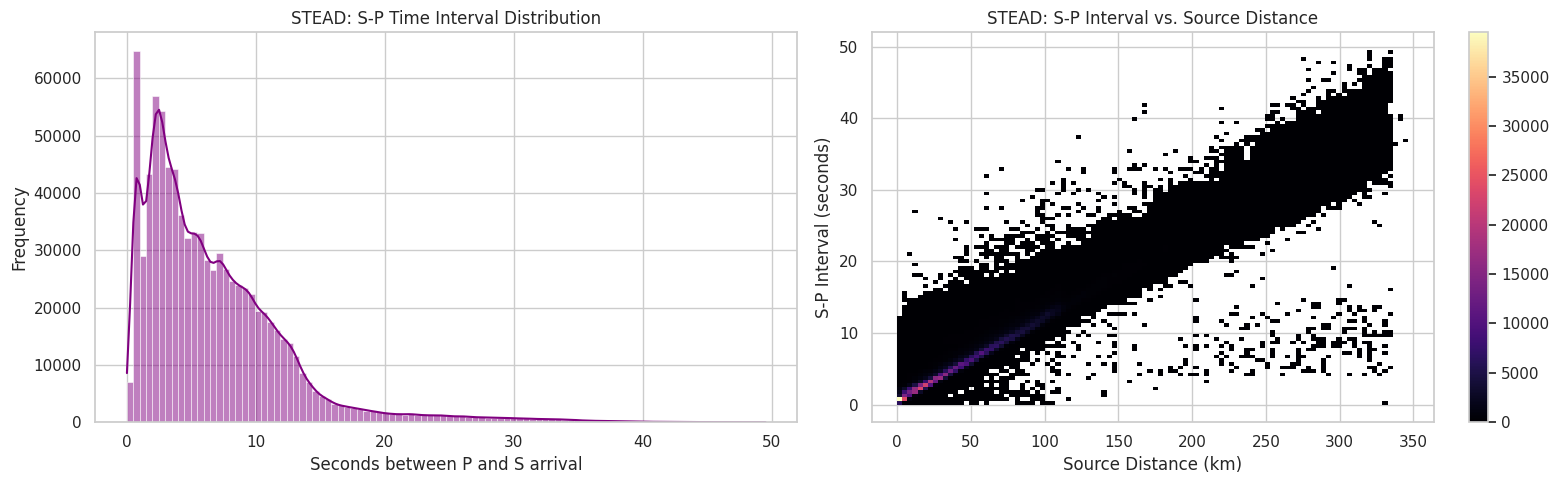

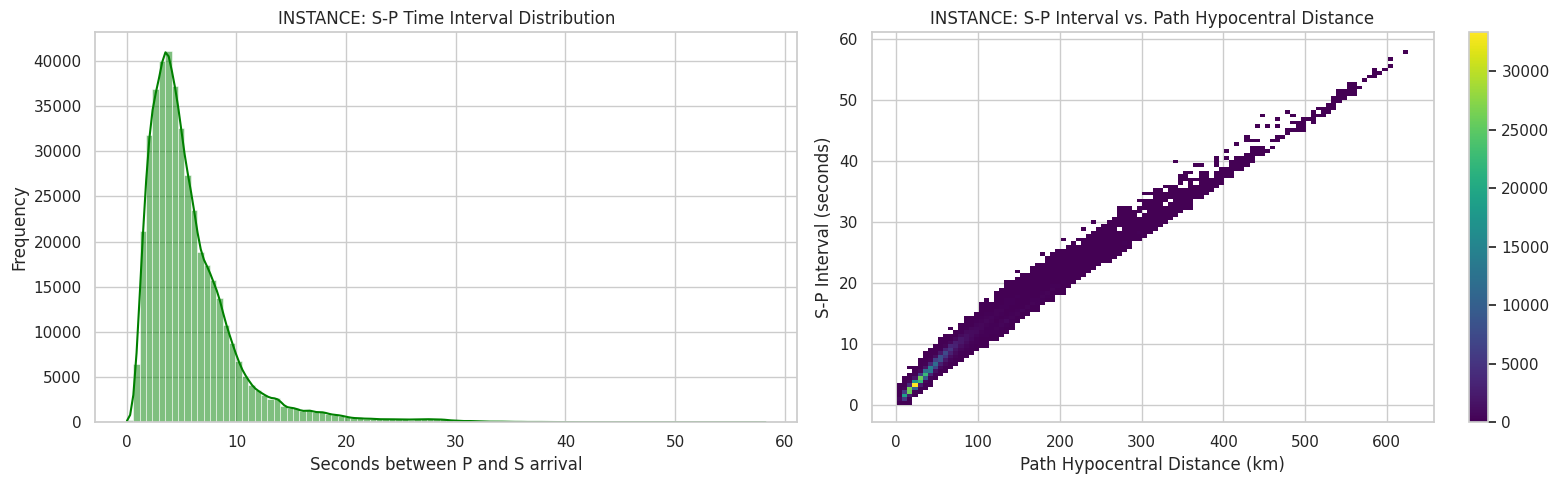

In [6]:
stead_eqs = stead_eqs.copy()
stead_eqs['s_p_interval_sec'] = (stead_eqs['trace_s_arrival_sample'] - stead_eqs['trace_p_arrival_sample']) / 100.0

valid_intervals = stead_eqs[
    (stead_eqs['s_p_interval_sec'] > 0) & 
    (stead_eqs['source_distance_km'].notna())
]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(
    data=valid_intervals, 
    x='s_p_interval_sec', 
    bins=100, 
    color='purple', 
    kde=True, 
    ax=axes[0]
)
axes[0].set_title("STEAD: S-P Time Interval Distribution")
axes[0].set_xlabel("Seconds between P and S arrival")
axes[0].set_ylabel("Frequency")

sns.histplot(
    data=valid_intervals, 
    x='source_distance_km', 
    y='s_p_interval_sec', 
    bins=100, 
    cmap='magma',
    cbar=True,
    ax=axes[1]
)
axes[1].set_title("STEAD: S-P Interval vs. Source Distance")
axes[1].set_xlabel("Source Distance (km)")
axes[1].set_ylabel("S-P Interval (seconds)")

plt.tight_layout()
plt.show()

instance_eqs = instance_eqs.copy()
instance_eqs['s_p_interval_sec'] = (instance_eqs['trace_S_arrival_sample'] - instance_eqs['trace_P_arrival_sample']) / 100.0
valid_intervals_instance = instance_eqs[
    (instance_eqs['s_p_interval_sec'] > 0) & 
    (instance_eqs['path_hyp_distance_km'].notna())
]
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.histplot(
    data=valid_intervals_instance, 
    x='s_p_interval_sec', 
    bins=100, 
    color='green', 
    kde=True, 
    ax=axes[0]
)
axes[0].set_title("INSTANCE: S-P Time Interval Distribution")
axes[0].set_xlabel("Seconds between P and S arrival")
axes[0].set_ylabel("Frequency")
sns.histplot(
    data=valid_intervals_instance, 
    x='path_hyp_distance_km', 
    y='s_p_interval_sec', 
    bins=100, 
    cmap='viridis',
    cbar=True,
    ax=axes[1]
)
axes[1].set_title("INSTANCE: S-P Interval vs. Path Hypocentral Distance")
axes[1].set_xlabel("Path Hypocentral Distance (km)")
axes[1].set_ylabel("S-P Interval (seconds)")
plt.tight_layout()
plt.show()

## Source distance vs Magnitude Analysis

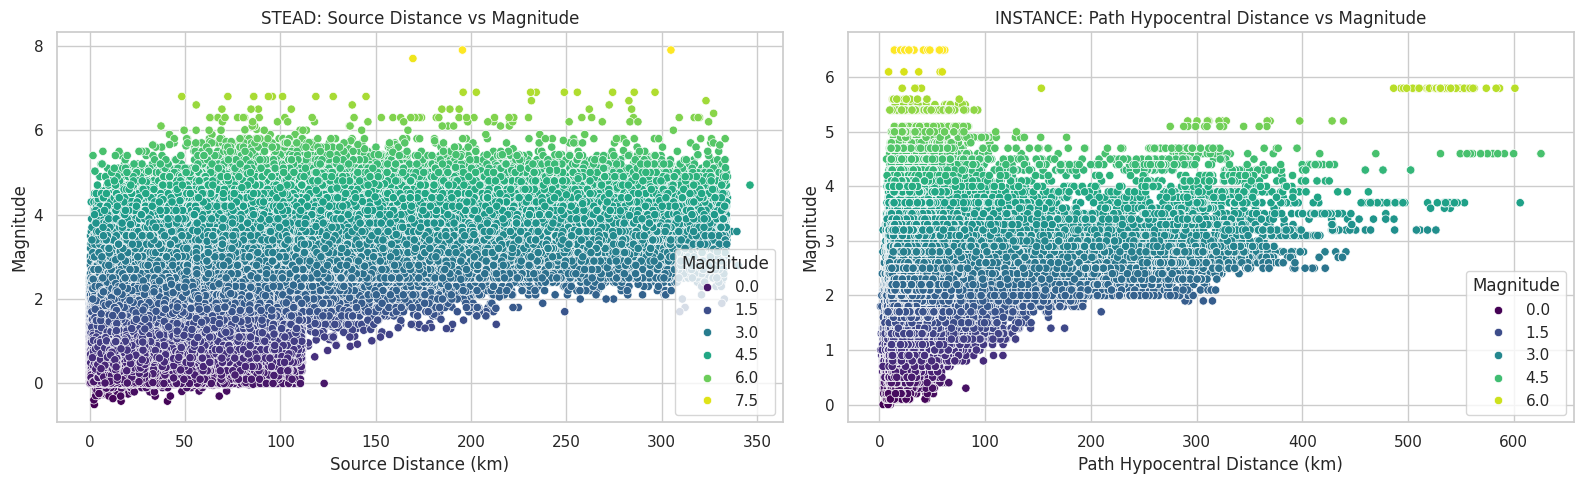

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.scatterplot(
    data=stead_eqs.dropna(subset=['source_distance_km', 'source_magnitude']),
    x='source_distance_km',
    y='source_magnitude',
    hue='source_magnitude',
    palette='viridis',
    ax=axes[0],
)
axes[0].set_title("STEAD: Source Distance vs Magnitude")
axes[0].set_xlabel("Source Distance (km)")
axes[0].set_ylabel("Magnitude")
axes[0].legend(title='Magnitude', loc='lower right')

sns.scatterplot(
    data=instance_eqs.dropna(subset=['path_hyp_distance_km', 'source_magnitude']),
    x='path_hyp_distance_km',
    y='source_magnitude',
    hue='source_magnitude',
    palette='viridis',
    ax=axes[1],
)
axes[1].set_title("INSTANCE: Path Hypocentral Distance vs Magnitude")
axes[1].set_xlabel("Path Hypocentral Distance (km)")
axes[1].set_ylabel("Magnitude")
axes[1].legend(title='Magnitude', loc='lower right')

plt.tight_layout()
plt.show()

## Number of traces with missing S or P waves

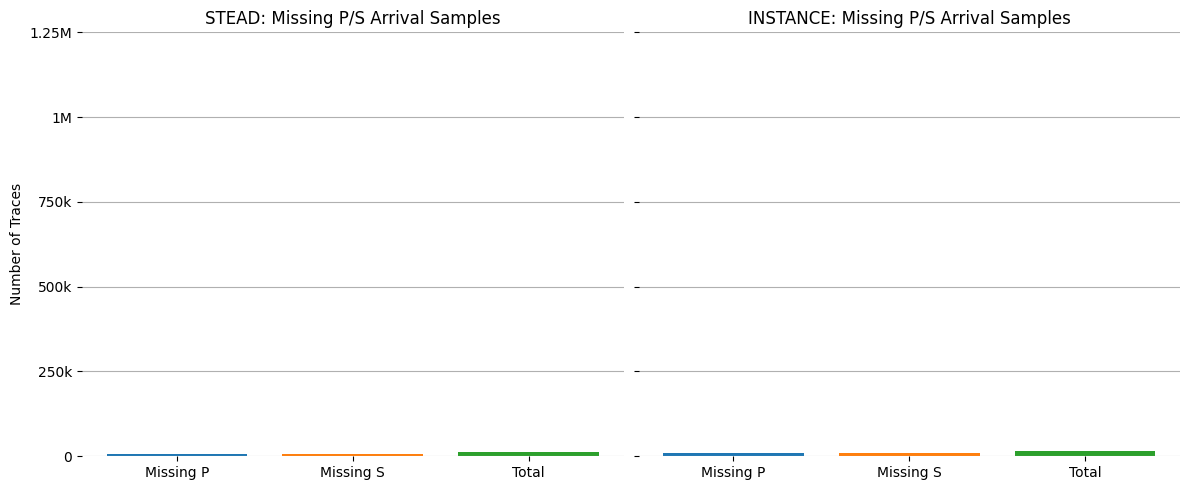

In [29]:
stead_missing_p = df_stead['trace_p_arrival_sample'].isna().sum()
stead_missing_s = df_stead['trace_s_arrival_sample'].isna().sum()
stead_total = len(df_stead)
yticks = [0, 250_000, 500_000, 750_000, 1_000_000, 1_250_000]
ytick_labels = ['0', '250k', '500k', '750k', '1M', '1.25M']

instance_missing_p = df_instance['trace_P_arrival_sample'].isna().sum()
instance_missing_s = df_instance['trace_S_arrival_sample'].isna().sum()
instance_total = len(df_instance)

categories = ['Missing P', 'Missing S', 'Total']

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

axes[0].bar(categories, [stead_missing_p, stead_missing_s, stead_total], color=['#1f77b4', '#ff7f0e', '#2ca02c'])
axes[0].set_title("STEAD: Missing P/S Arrival Samples")
axes[0].set_ylabel("Number of Traces")

axes[1].bar(categories, [instance_missing_p, instance_missing_s, instance_total], color=['#1f77b4', '#ff7f0e', '#2ca02c'])
axes[1].set_title("INSTANCE: Missing P/S Arrival Samples")

for ax in axes:
    ax.set_yticks(yticks)
    ax.set_yticklabels(ytick_labels)
    ax.set_frame_on(False)
    ax.grid(axis='y')
plt.tight_layout()
plt.show()

In [12]:
# 1. Helper function to calculate mutually exclusive wave counts
def get_wave_counts(df, p_col, s_col):
    p_missing = df[p_col].isna()
    s_missing = df[s_col].isna()
    
    return {
        'Has both P and S': (~p_missing & ~s_missing).sum(),
        'Missing P': (p_missing & ~s_missing).sum(),
        'Missing S': (~p_missing & s_missing).sum(),
        'Missing both': (p_missing & s_missing).sum()
    }

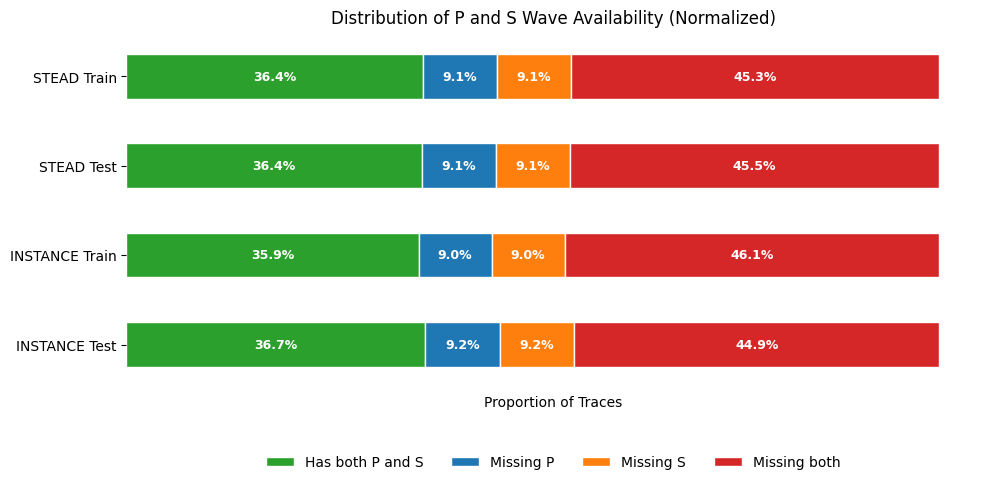

In [ ]:
# 1. Filtered data retrieval (Earthquakes only)
# STEAD earthquake label: 'earthquake_local' | INSTANCE earthquake label: 'InstanceCounts'
data = {
    'STEAD Train': get_wave_counts(
        df_stead_train[df_stead_train['trace_category'] == 'earthquake_local'], 
        'trace_p_arrival_sample', 'trace_s_arrival_sample'
    ),
    'STEAD Test': get_wave_counts(
        df_stead_test[df_stead_test['trace_category'] == 'earthquake_local'], 
        'trace_p_arrival_sample', 'trace_s_arrival_sample'
    ),
    'INSTANCE Train': get_wave_counts(
        df_instance_train[df_instance_train['trace_dataset'] == 'InstanceCounts'], 
        'trace_P_arrival_sample', 'trace_S_arrival_sample'
    ),
    'INSTANCE Test': get_wave_counts(
        df_instance_test[df_instance_test['trace_dataset'] == 'InstanceCounts'], 
        'trace_P_arrival_sample', 'trace_S_arrival_sample'
    )
}

# Convert to DataFrame
df_counts = pd.DataFrame(data).T 

# 3. Normalize the rows to proportions (summing to 1.0) so all bars are the same length
df_proportions = df_counts.div(df_counts.sum(axis=1), axis=0)

# 4. Plotting
fig, ax = plt.subplots(figsize=(10, 5))

# Use pandas' built-in stacked horizontal bar plotting
colors = ['#2ca02c', '#1f77b4', '#ff7f0e', '#d62728'] # Green, Blue, Orange, Red
df_proportions.plot(kind='barh', stacked=True, ax=ax, color=colors, edgecolor='white')

# Add percentage labels
for c in ax.containers:
    # Custom labels: v.get_width() is the proportion. 
    # We only show the label if the section is wider than 3% (0.03)
    labels = [f'{v.get_width()*100:.1f}%' if v.get_width() > 0.03 else '' for v in c]
    
    ax.bar_label(c, labels=labels, label_type='center', color='white', fontweight='bold', fontsize=9)

# 5. Formatting
ax.set_title("Distribution of P and S Wave Availability (Normalized)")
ax.set_xlabel("Proportion of Traces")
#ax.set_xlim(0, 1)
plt.xticks([])

# Invert y-axis to read top-to-bottom: STEAD Train -> INSTANCE Test
ax.invert_yaxis()

# Move the legend to the bottom, spread across 4 columns
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=4, frameon=False)
plt.box(False)
plt.tight_layout()
plt.show()

## Calculate the number of unique stations that recorded each event

STEAD: Summary of stations per event
count    405672.000000
mean          2.121672
std           1.888560
min           1.000000
25%           1.000000
50%           1.000000
75%           3.000000
max          42.000000
Name: station_code, dtype: float64
Total number of stations in STEAD: 3187

INSTANCE: Summary of stations per event
count    79271.000000
mean         7.543654
std         11.917678
min          1.000000
25%          1.000000
50%          2.000000
75%          9.000000
max        167.000000
Name: station_code, dtype: float64

Total number of stations in INSTANCE: 620


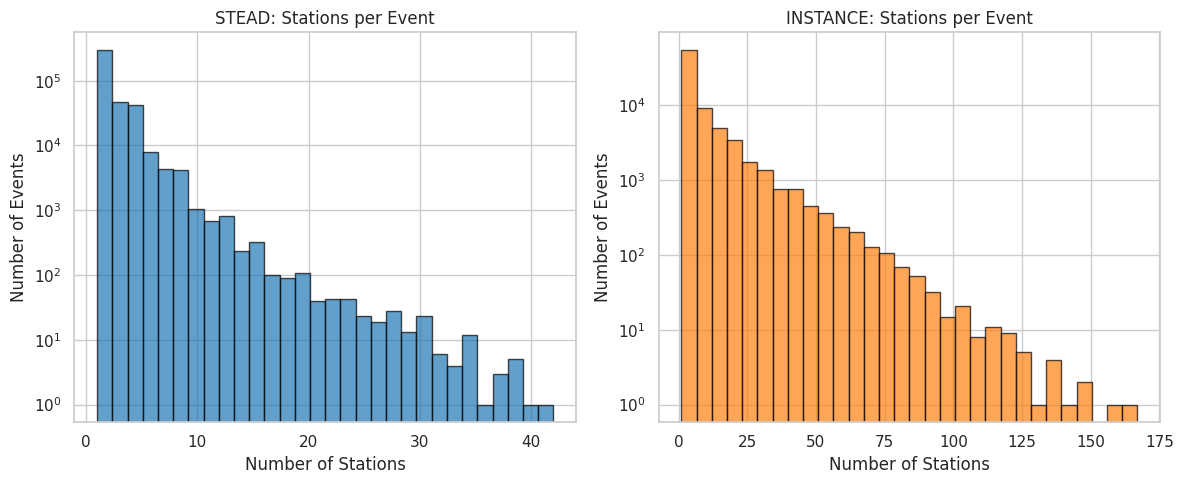

In [12]:
# For STEAD
stead_station_col = 'receiver_code' if 'receiver_code' in df_stead.columns else 'station_code'
stead_stations_per_event = df_stead.groupby('source_id')[stead_station_col].nunique()

print("STEAD: Summary of stations per event")
print(stead_stations_per_event.describe())
print(f"Total number of stations in STEAD: {df_stead[stead_station_col].nunique()}")

# For INSTANCE
instance_station_col = 'station_code' if 'station_code' in df_instance.columns else 'receiver_code'
instance_stations_per_event = df_instance.groupby('source_id')[instance_station_col].nunique()

print("\nINSTANCE: Summary of stations per event")
print(instance_stations_per_event.describe())
print(f"\nTotal number of stations in INSTANCE: {df_instance[instance_station_col].nunique()}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=False)

# STEAD Histogram
axes[0].hist(stead_stations_per_event, bins=30, color='#1f77b4', edgecolor='black', alpha=0.7)
axes[0].set_title("STEAD: Stations per Event")
axes[0].set_xlabel("Number of Stations")
axes[0].set_ylabel("Number of Events")
axes[0].set_yscale('log')

# INSTANCE Histogram
axes[1].hist(instance_stations_per_event, bins=30, color='#ff7f0e', edgecolor='black', alpha=0.7)
axes[1].set_title("INSTANCE: Stations per Event")
axes[1].set_xlabel("Number of Stations")
axes[1].set_ylabel("Number of Events")
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

In [25]:
import numpy as np

In [26]:
from scipy.signal import fftconvolve
def apply_cwt(trace, sf=100.0, num_bins=32, f_min=0.5, f_max=45.0, B=1.5, C=1.0):
    """
    Applies a Complex Morlet CWT to a raw NumPy array at its ORIGINAL time resolution.
    
    Args:
        trace: 1D array (Time,) or 2D array (Channels, Time). E.g., shape (3, 6000).
        sf: Original sampling frequency (Hz), defaulted to 100 for STEAD/INSTANCE.
        num_bins: Number of frequency scales
        f_min, f_max: Frequency range
        B: Bandwidth parameter
        C: Center frequency parameter
        
    Returns:
        cwt_mag: Array of shape (Channels, Freqs, Time). E.g., (3, 32, 6000).
    """
    # 1. Handle 1D or Multi-channel inputs consistently
    is_1d = trace.ndim == 1
    trace_2d = np.atleast_2d(trace)
    num_channels, seq_len = trace_2d.shape

    # 2. Generate logarithmic frequency bins and corresponding scales based on 100 Hz
    freqs = np.logspace(np.log10(f_min), np.log10(f_max), num_bins)
    scales = C / (freqs * (1.0 / sf))

    # 3. Define the temporal grid for the wavelet
    max_scale = scales[0] 
    window_len = int(10 * max_scale)
    if window_len % 2 == 0:
        window_len += 1 # Ensure there is a perfect center point
        
    t = np.arange(-window_len // 2 + 1, window_len // 2 + 1)
    
    # Initialize the output array. 
    # seq_len will remain 6000, keeping full temporal precision.
    cwt_mag = np.zeros((num_channels, num_bins, seq_len), dtype=np.float32)
    
    # 4. Construct and apply the Complex Morlet wavelet for each scale
    for i, s in enumerate(scales):
        x = t / s
        norm = 1.0 / np.sqrt(np.pi * B)
        gauss = np.exp(-(x**2) / B)
        
        # Real and Imaginary components (normalized by 1/sqrt(s))
        real_w = norm * np.cos(2 * np.pi * C * x) * gauss / np.sqrt(s)
        imag_w = norm * np.sin(2 * np.pi * C * x) * gauss / np.sqrt(s)
        
        # Apply the filters to each channel
        for ch in range(num_channels):
            # mode='same' guarantees the output length matches the input trace exactly
            real_out = fftconvolve(trace_2d[ch], real_w, mode='same')
            imag_out = fftconvolve(trace_2d[ch], imag_w, mode='same')
            
            # Calculate absolute magnitude
            cwt_mag[ch, i, :] = np.sqrt(real_out**2 + imag_out**2)
            
    times = np.arange(seq_len) / sf
    
    # Return the correct times array instead of the kernel array 't'
    out_mag = cwt_mag[0] if is_1d else cwt_mag
    return out_mag, freqs, times

In [27]:
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.ticker as ticker
from matplotlib.ticker import ScalarFormatter

def visualize_seismic_cwt(trace, cwt_data, freqs, times, p_arrival=None, s_arrival=None, title="Seismic Trace CWT Analysis"):
    """
    trace: 1D array of the seismic signal (single channel)
    cwt_data: 2D array (Freqs x Time) of the CWT magnitude
    freqs: 1D array of frequency bin values
    times: 1D array of time values
    p_arrival: time (in seconds) of P-arrival
    s_arrival: time (in seconds) of S-arrival
    """
    
    # Set the style for colorblind friendliness and clarity
    sns.set_theme(style="whitegrid")
    
    # Create figure with two subplots sharing the X-axis
    fig = plt.figure(figsize=(12, 8))

    gs = fig.add_gridspec(2, 2, height_ratios=[1, 2], width_ratios=[40, 1], hspace=0.05, wspace=0.02)
    
    ax_sig = fig.add_subplot(gs[0, 0])      # Top Left: Signal
    ax_spec = fig.add_subplot(gs[1, 0])     # Bottom Left: Heatmap
    ax_cbar = fig.add_subplot(gs[1, 1])     # Bottom Right: Colorbar
    
    # --- Plot 1: Raw Signal ---
    ax_sig.plot(times, trace, color="#4c72b0", linewidth=1.0)
    ax_sig.set_ylabel("Amplitude")
    ax_sig.set_title(title, loc='center', fontweight='bold', fontsize=14, pad=15)

    # Remove x-ticks from signal plot but keep the axis (since it shares time with heatmap)
    plt.setp(ax_sig.get_xticklabels(), visible=False)
    
    # --- Plot 2: CWT Heatmap ---
    # We use the 'rocket' or 'magma' colormap: both are perceptually uniform and colorblind friendly
    # The 'vlag' or 'icefire' are also good, but 'rocket' highlights energy peaks best.
    img = ax_spec.pcolormesh(times, freqs, cwt_data, cmap='rocket', shading='gouraud')
    
    # Frequency Axis Formatting
    ax_spec.set_yscale('log')
    tick_values = [0.25, 0.5, 1, 2, 4, 8, 16, 32
                   ]
    ax_spec.set_yticks(tick_values)
    ax_spec.yaxis.set_major_formatter(ScalarFormatter())
    ax_spec.set_ylabel("Frequency (Hz)")
    ax_spec.set_xlabel("Time (s)")
    ax_spec.set_ylim(freqs.min(), freqs.max())

    # --- Plot 3: Colorbar ---
    # We place the cbar in the dedicated ax_cbar
    cbar = fig.colorbar(img, cax=ax_cbar)
    cbar.set_label("Log Magnitude", rotation=270, labelpad=15)
    
    # --- Identification Lines ---
    arrivals = [(p_arrival, 'P', '#e67e22'), (s_arrival, 'S', '#e74c3c')]
    for arr_time, label, color in arrivals:
        if arr_time is not None:
            for ax in [ax_sig, ax_spec]:
                ax.axvline(x=arr_time, color=color, linestyle='-', linewidth=2, alpha=0.9)
            ax_sig.text(arr_time, ax_sig.get_ylim()[1], f' {label}', 
                        color=color, fontweight='bold', va='bottom')

    # Tighten layout to ensure axes align
    #plt.tight_layout()
    plt.subplots_adjust(hspace=0.05) # Remove vertical gap between plots
    
    return fig

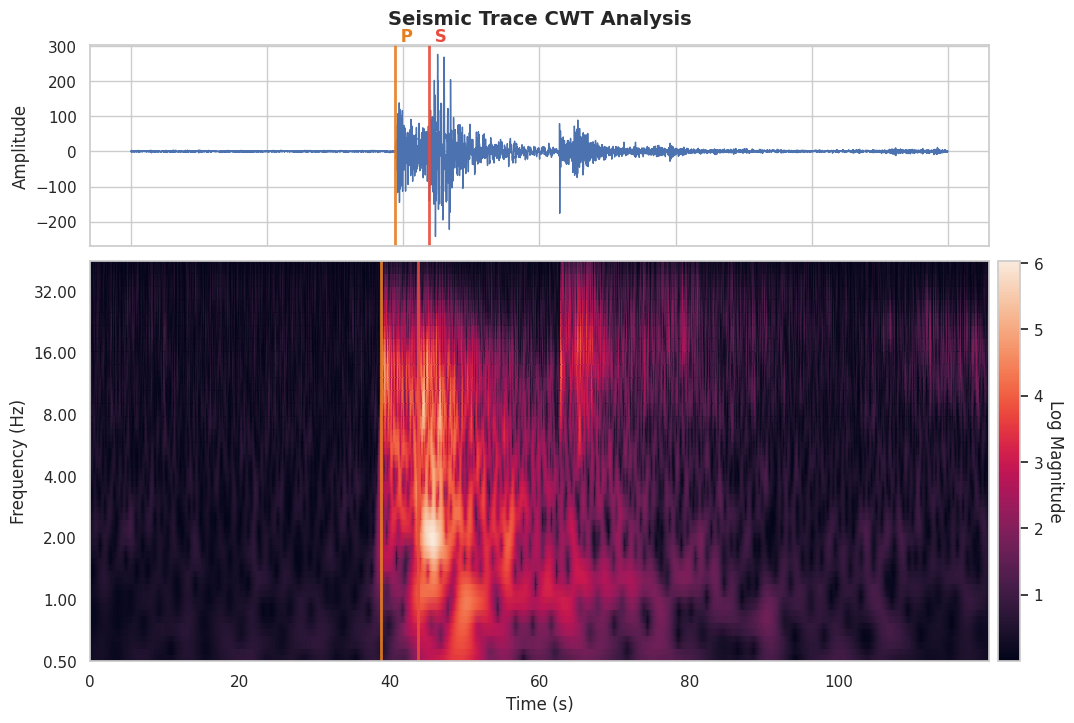

In [ ]:
# Generate cwt visualization
idx = 80000  # index de la trace à visualiser
trace = instance.get_waveforms(idx)[0] # juste 1 dimension pour la visualisation
metadata = df_instance.iloc[idx] # metadonnées de la trace

sr = metadata["trace_sampling_rate_hz"] # samplerate de la trace
p_arrival_time = metadata['trace_P_arrival_sample'] / sr
s_arrival_time = metadata['trace_S_arrival_sample'] / sr

cwt_mag, freqs, times = apply_cwt(trace, sr, num_bins=64, f_min=0.5, f_max=128)
log_cwt_numpy = np.log1p(cwt_mag)
fig = visualize_seismic_cwt(trace, log_cwt_numpy, freqs, times, p_arrival_time, s_arrival_time)
